# House Price Prediction — Overfitting Study with Dropout & L2 Regularization

A systematic comparison of three MLP architectures on the King County house sales dataset,  
demonstrating how dropout and L2 regularization improve generalization over a baseline model.

**Dataset:** [King County House Sales — Kaggle](https://www.kaggle.com/harlfoxem/housesalesprediction)  
**Task:** Regression — predict house sale price  
**Models:** Basic MLP → MLP + Dropout → MLP + L2 Regularization

## 1. Imports

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler, Callback
from tensorflow.keras.utils import get_file
from keras.regularizers import l2
# Removed 'from tensorflow.keras import backend as K' as it's no longer needed after removing K.get_value usage

## 2. Load Dataset

In [2]:
csv_path = get_file('kc_house_data.csv', origin='http://web.eece.maine.edu/~zhu/DL/kc_house_data.csv')
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nNull values:")
print(df.isnull().any())

2515206/2515206 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape: (21613, 21)

Null values:
id               False
date             False
price            False
bedrooms         False
bathrooms        False
sqft_living      False
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade            False
sqft_above       False
sqft_basement    False
yr_built         False
yr_renovated     False
zipcode          False
lat              False
long             False
sqft_living15    False
sqft_lot15       False
dtype: bool


In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# Parse date into year, month, day and select relevant columns
df['sale_yr']    = pd.to_numeric(df.date.str.slice(0, 4))
df['sale_month'] = pd.to_numeric(df.date.str.slice(4, 6))
df['sale_day']   = pd.to_numeric(df.date.str.slice(6, 8))

kc_data = pd.DataFrame(df, columns=[
    'sale_yr', 'sale_month', 'sale_day', 'waterfront',
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built',
    'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price'
])

kc_data.describe()

,sale_yr,sale_month,sale_day,waterfront,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04
mean,2014.322954,6.574423,15.688197,0.007542,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,3.409430,7.656873,1788.390691,291.509045,1971.005136,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,5.400881e+05
std,0.467616,3.115308,8.635063,0.086517,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.650743,1.175459,828.090978,442.575043,29.373411,53.505026,0.138564,0.140828,685.391304,27304.179631,3.671272e+05
min,2014.000000,1.000000,1.000000,0.000000,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,7.500000e+04
25%,2014.000000,4.000000,8.000000,0.000000,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,3.219500e+05
50%,2014.000000,6.000000,16.000000,0.000000,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,3.000000,7.000000,1560.000000,0.000000,1975.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,4.500000e+05
75%,2015.000000,9.000000,23.000000,0.000000,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,6.450000e+05
max,2015.000000,12.000000,31.000000,1.000000,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06


## 3. Exploratory Data Analysis

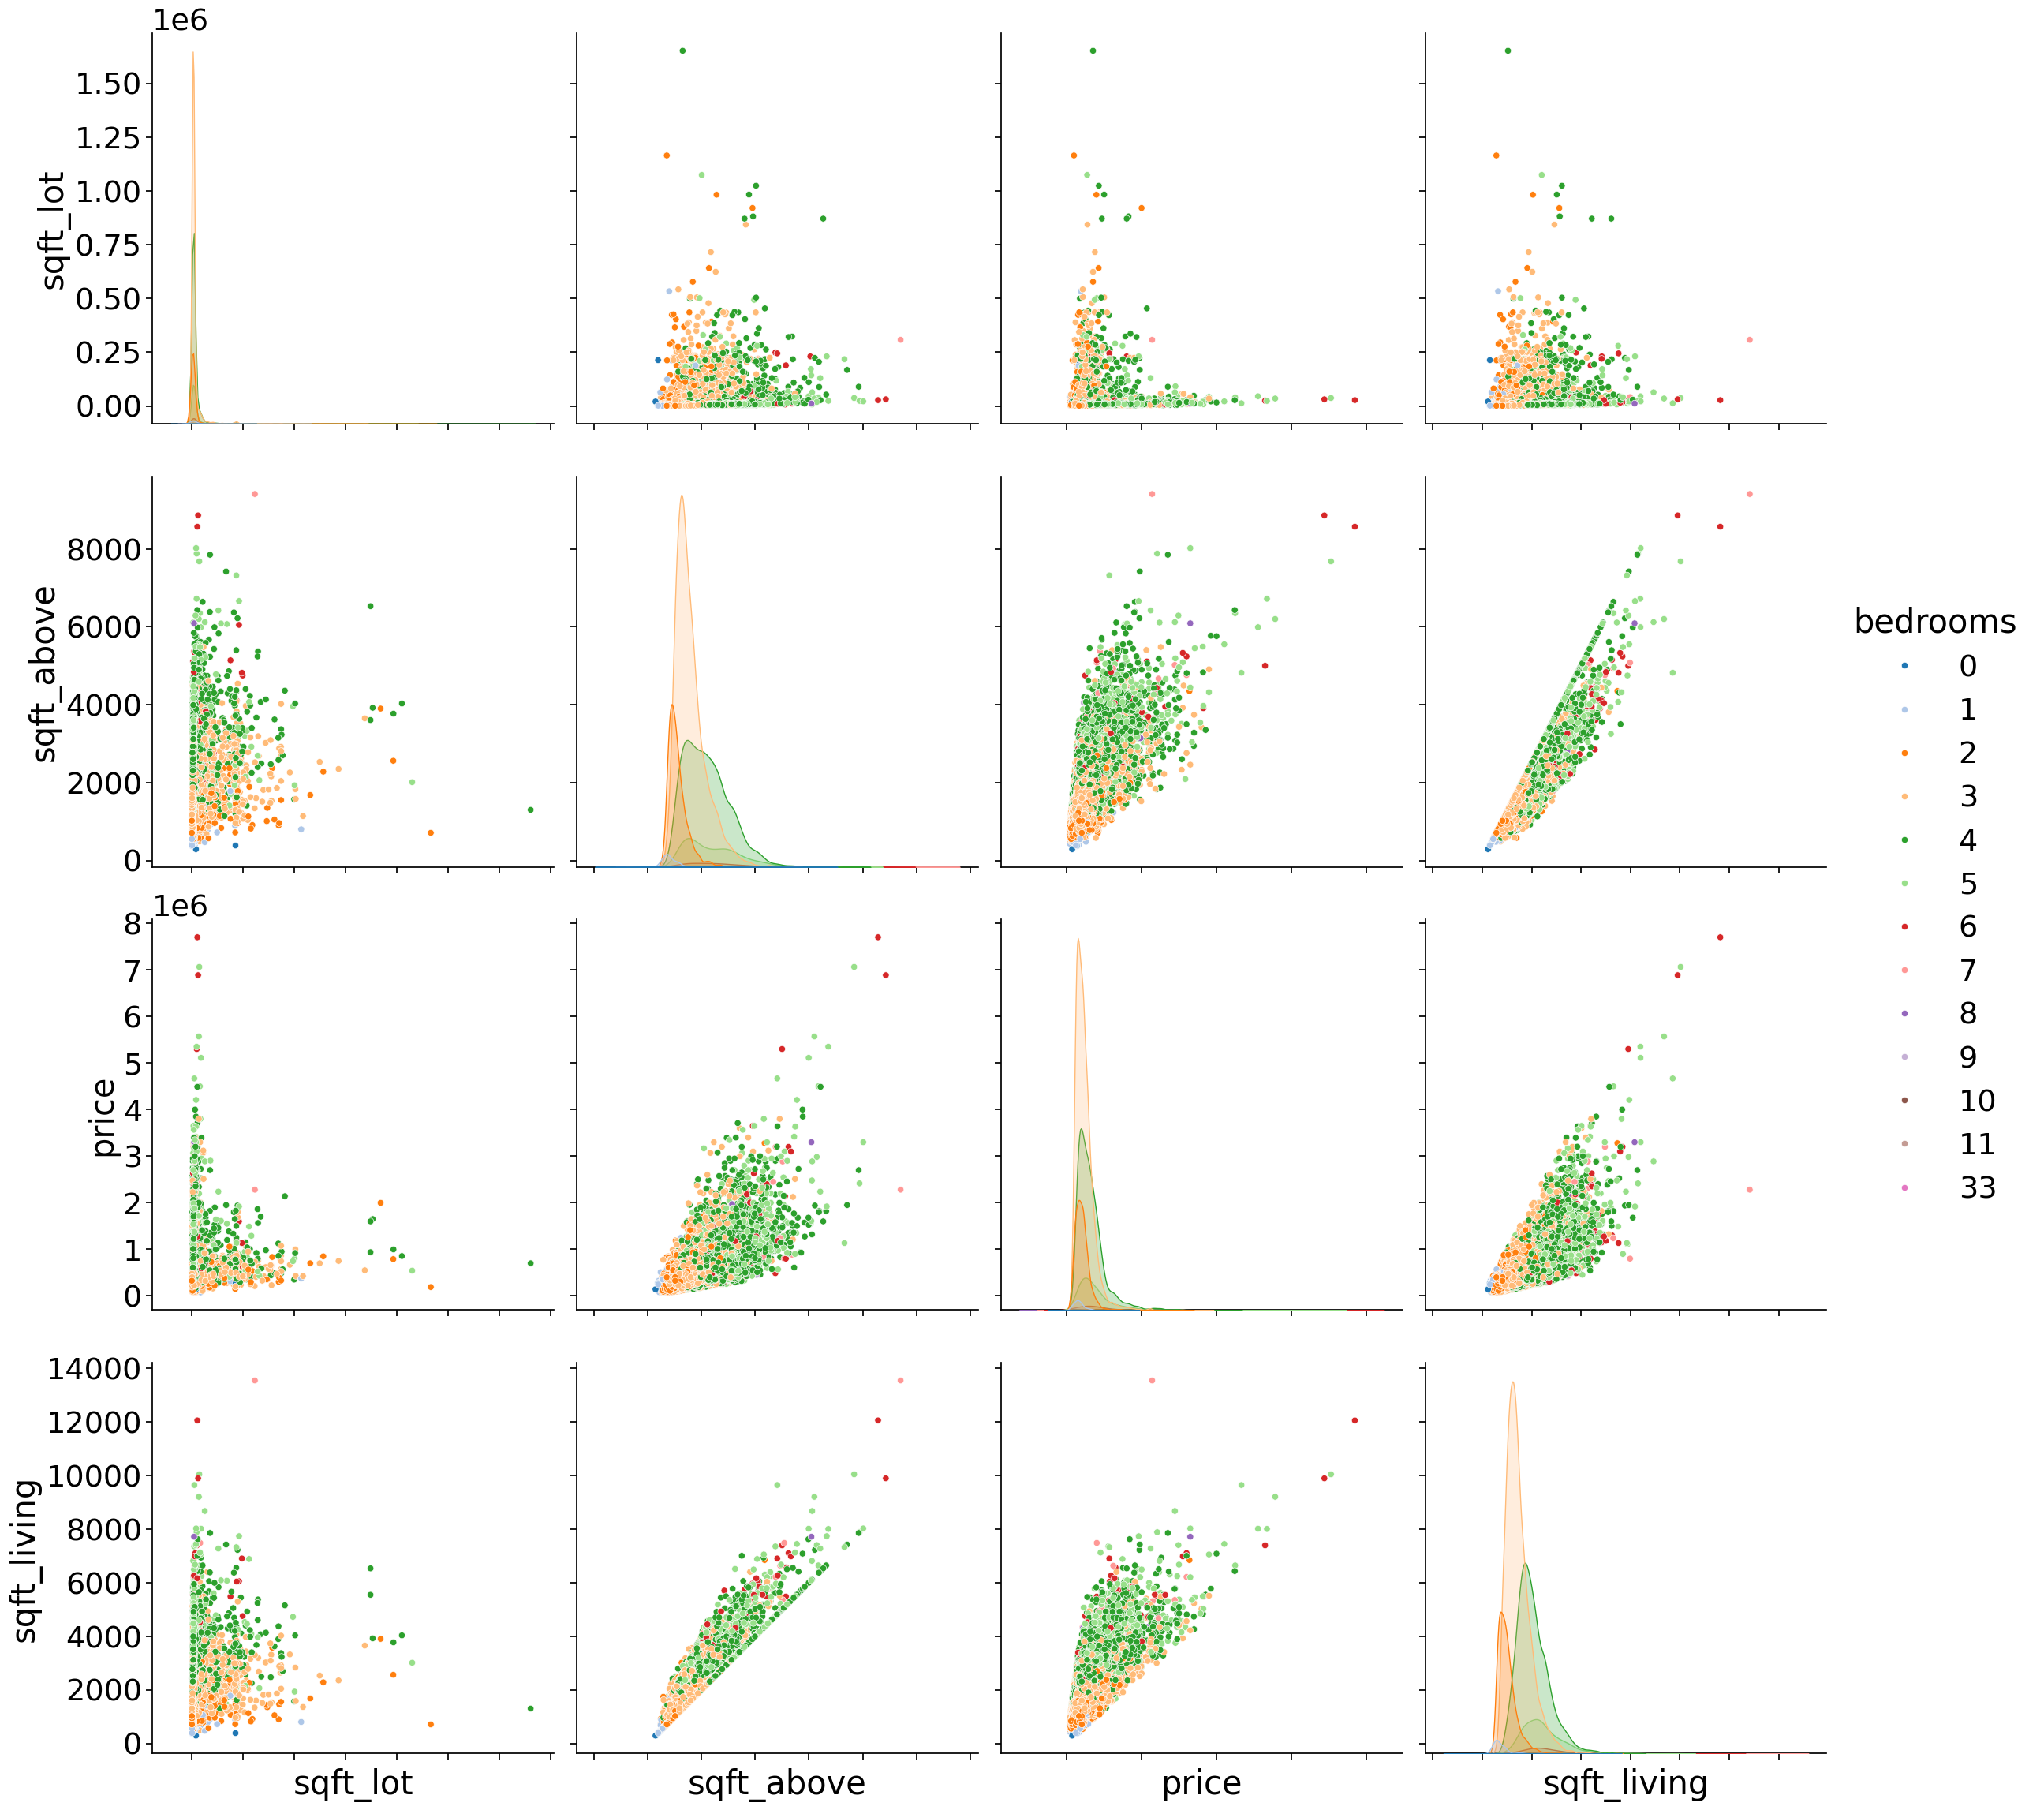

In [5]:
# Pairplot: key features colored by bedroom count
with sns.plotting_context("notebook", font_scale=2.5):
    g = sns.pairplot(
        df[['sqft_lot', 'sqft_above', 'price', 'sqft_living', 'bedrooms']],
        hue='bedrooms', palette='tab20', height=6
    )
g.set(xticklabels=[]);

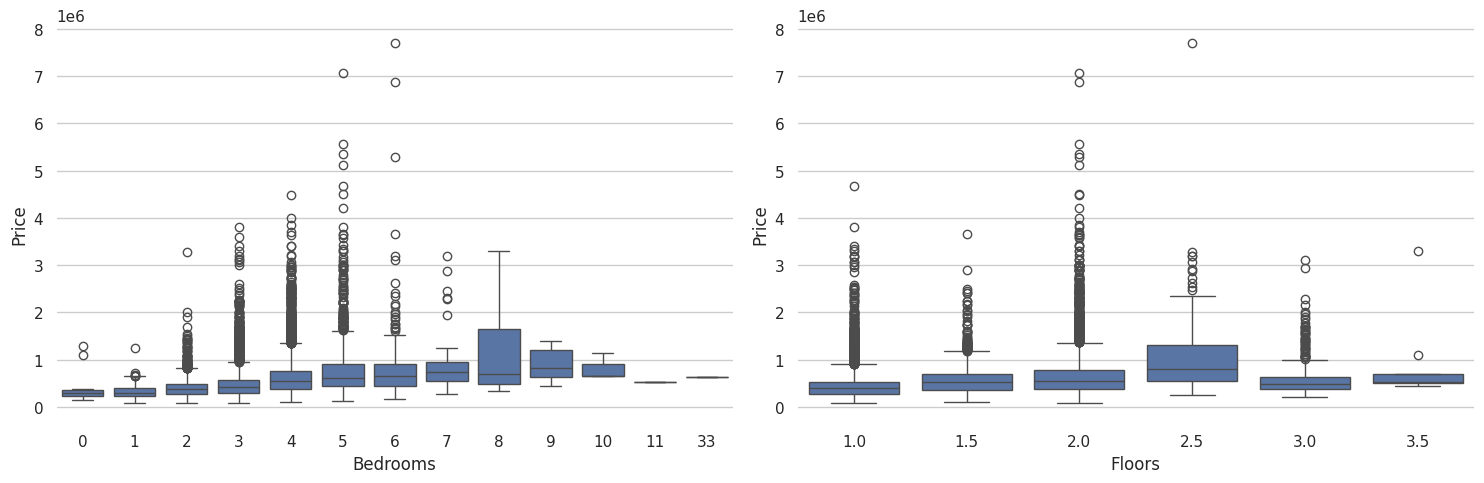

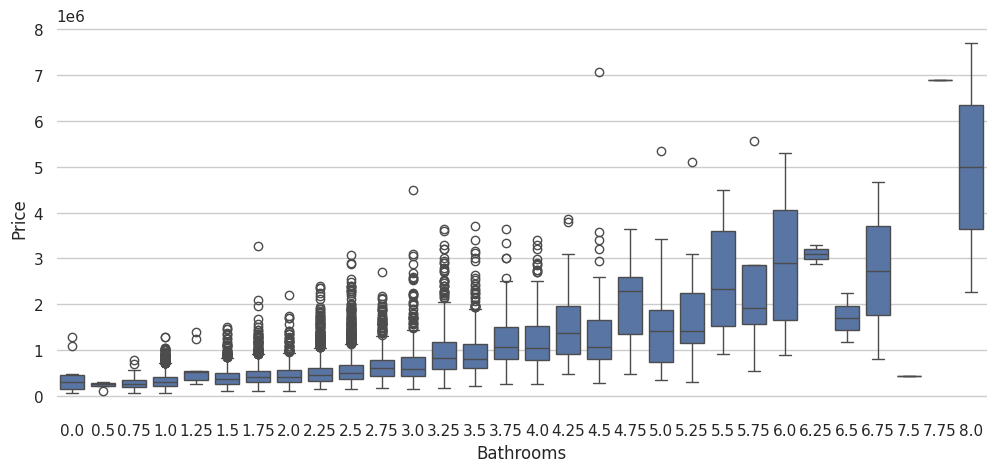

In [6]:
# Boxplots: price vs bedrooms, floors, bathrooms
sns.set(style="whitegrid", font_scale=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['bedrooms'], y=df['price'], ax=axes[0])
sns.boxplot(x=df['floors'],   y=df['price'], ax=axes[1])
axes[0].set(xlabel='Bedrooms', ylabel='Price')
axes[1].set(xlabel='Floors',   ylabel='Price')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x=df['bathrooms'], y=df['price'], ax=ax)
ax.set(xlabel='Bathrooms', ylabel='Price')
sns.despine(left=True, bottom=True)
plt.show()

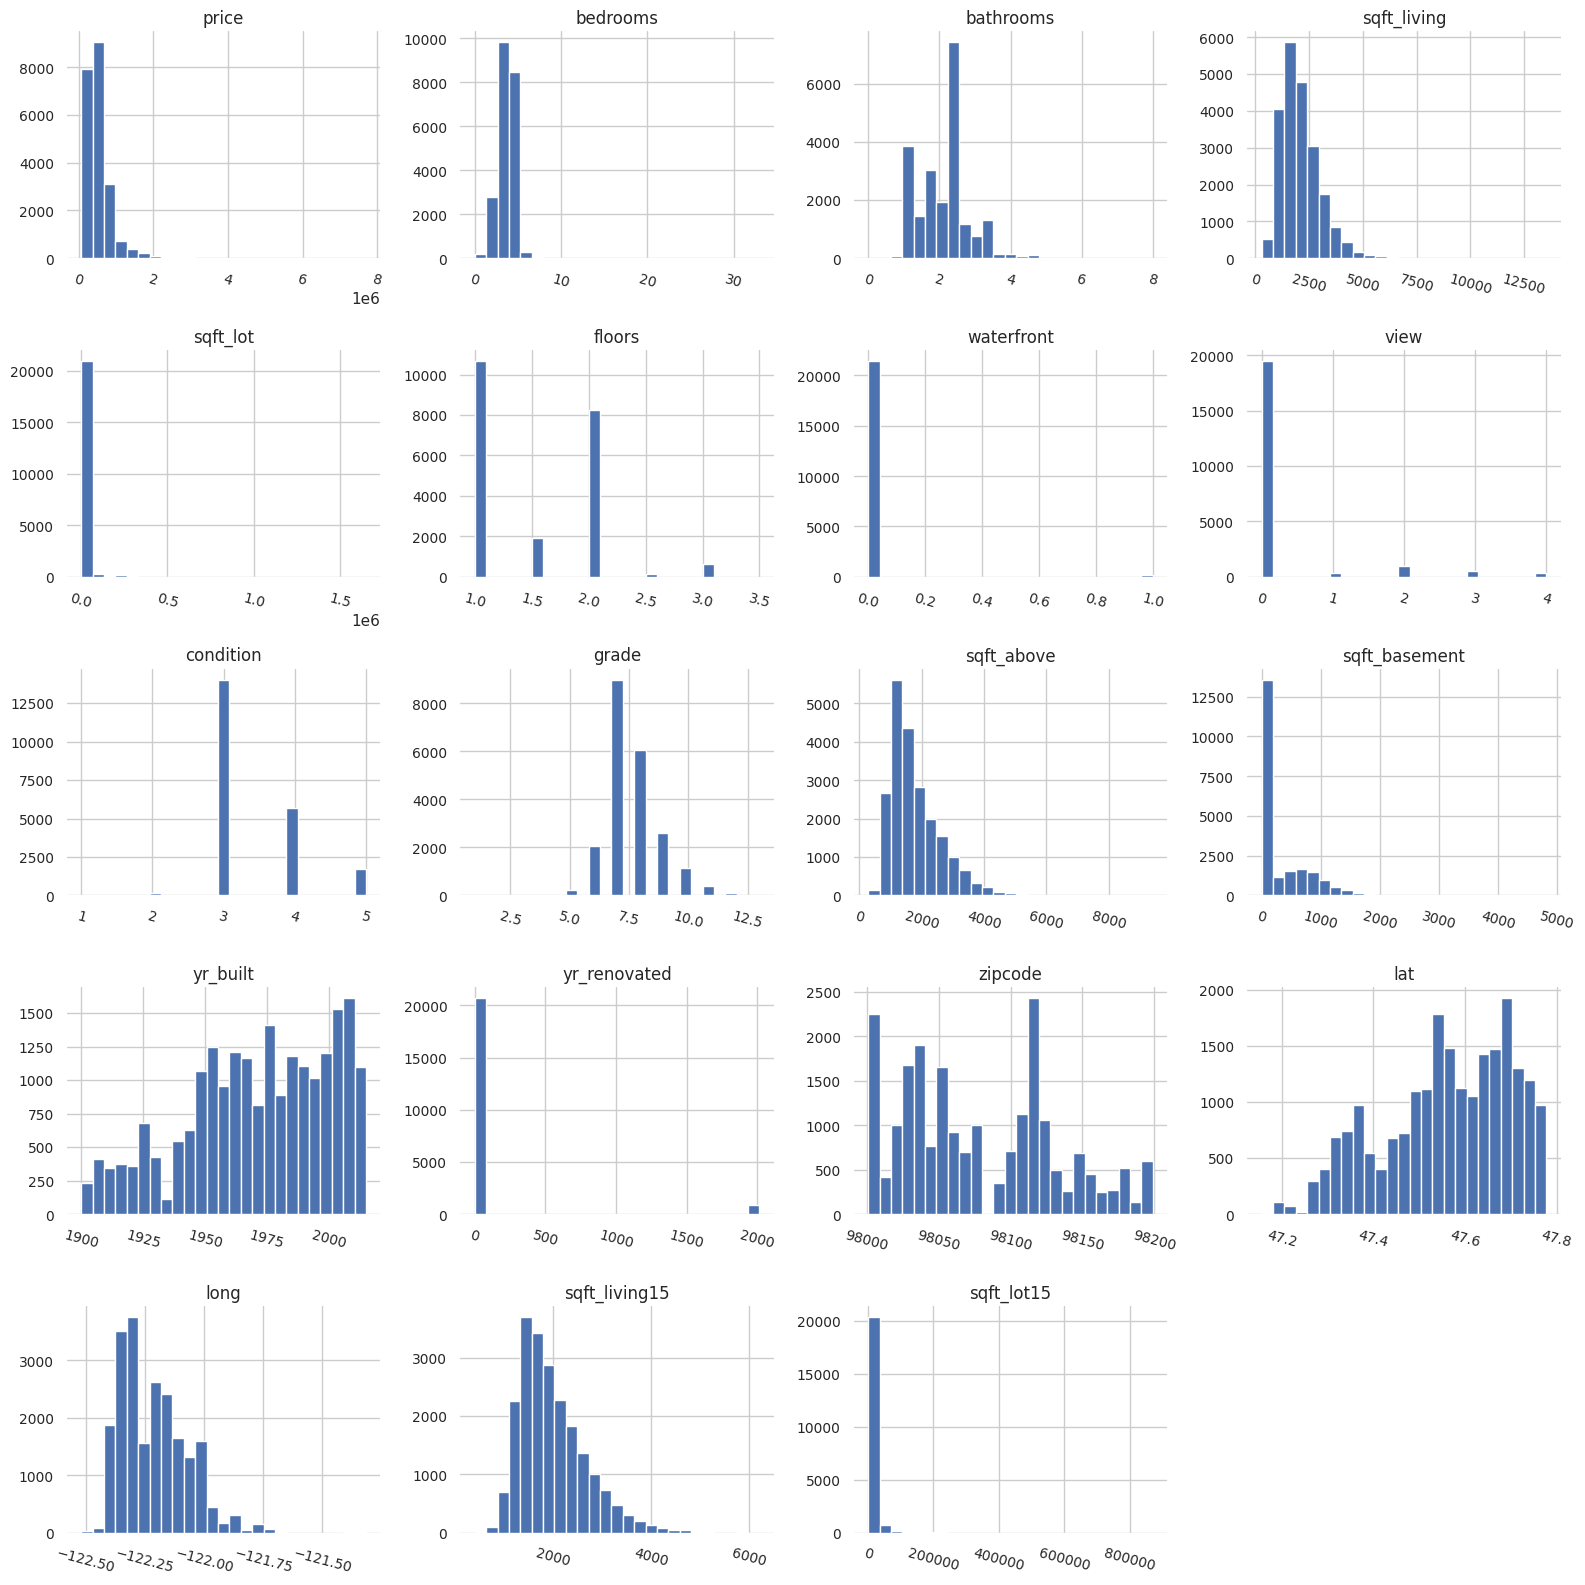

In [7]:
# Feature distribution histograms
df1 = df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
           'floors', 'waterfront', 'view', 'condition', 'grade',
           'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
           'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']]
h = df1.hist(bins=25, figsize=(16, 16), xlabelsize=10, ylabelsize=10, xrot=-15)
sns.despine(left=True, bottom=True)
[x.title.set_size(12) for x in h.ravel()]
plt.tight_layout()
plt.show()

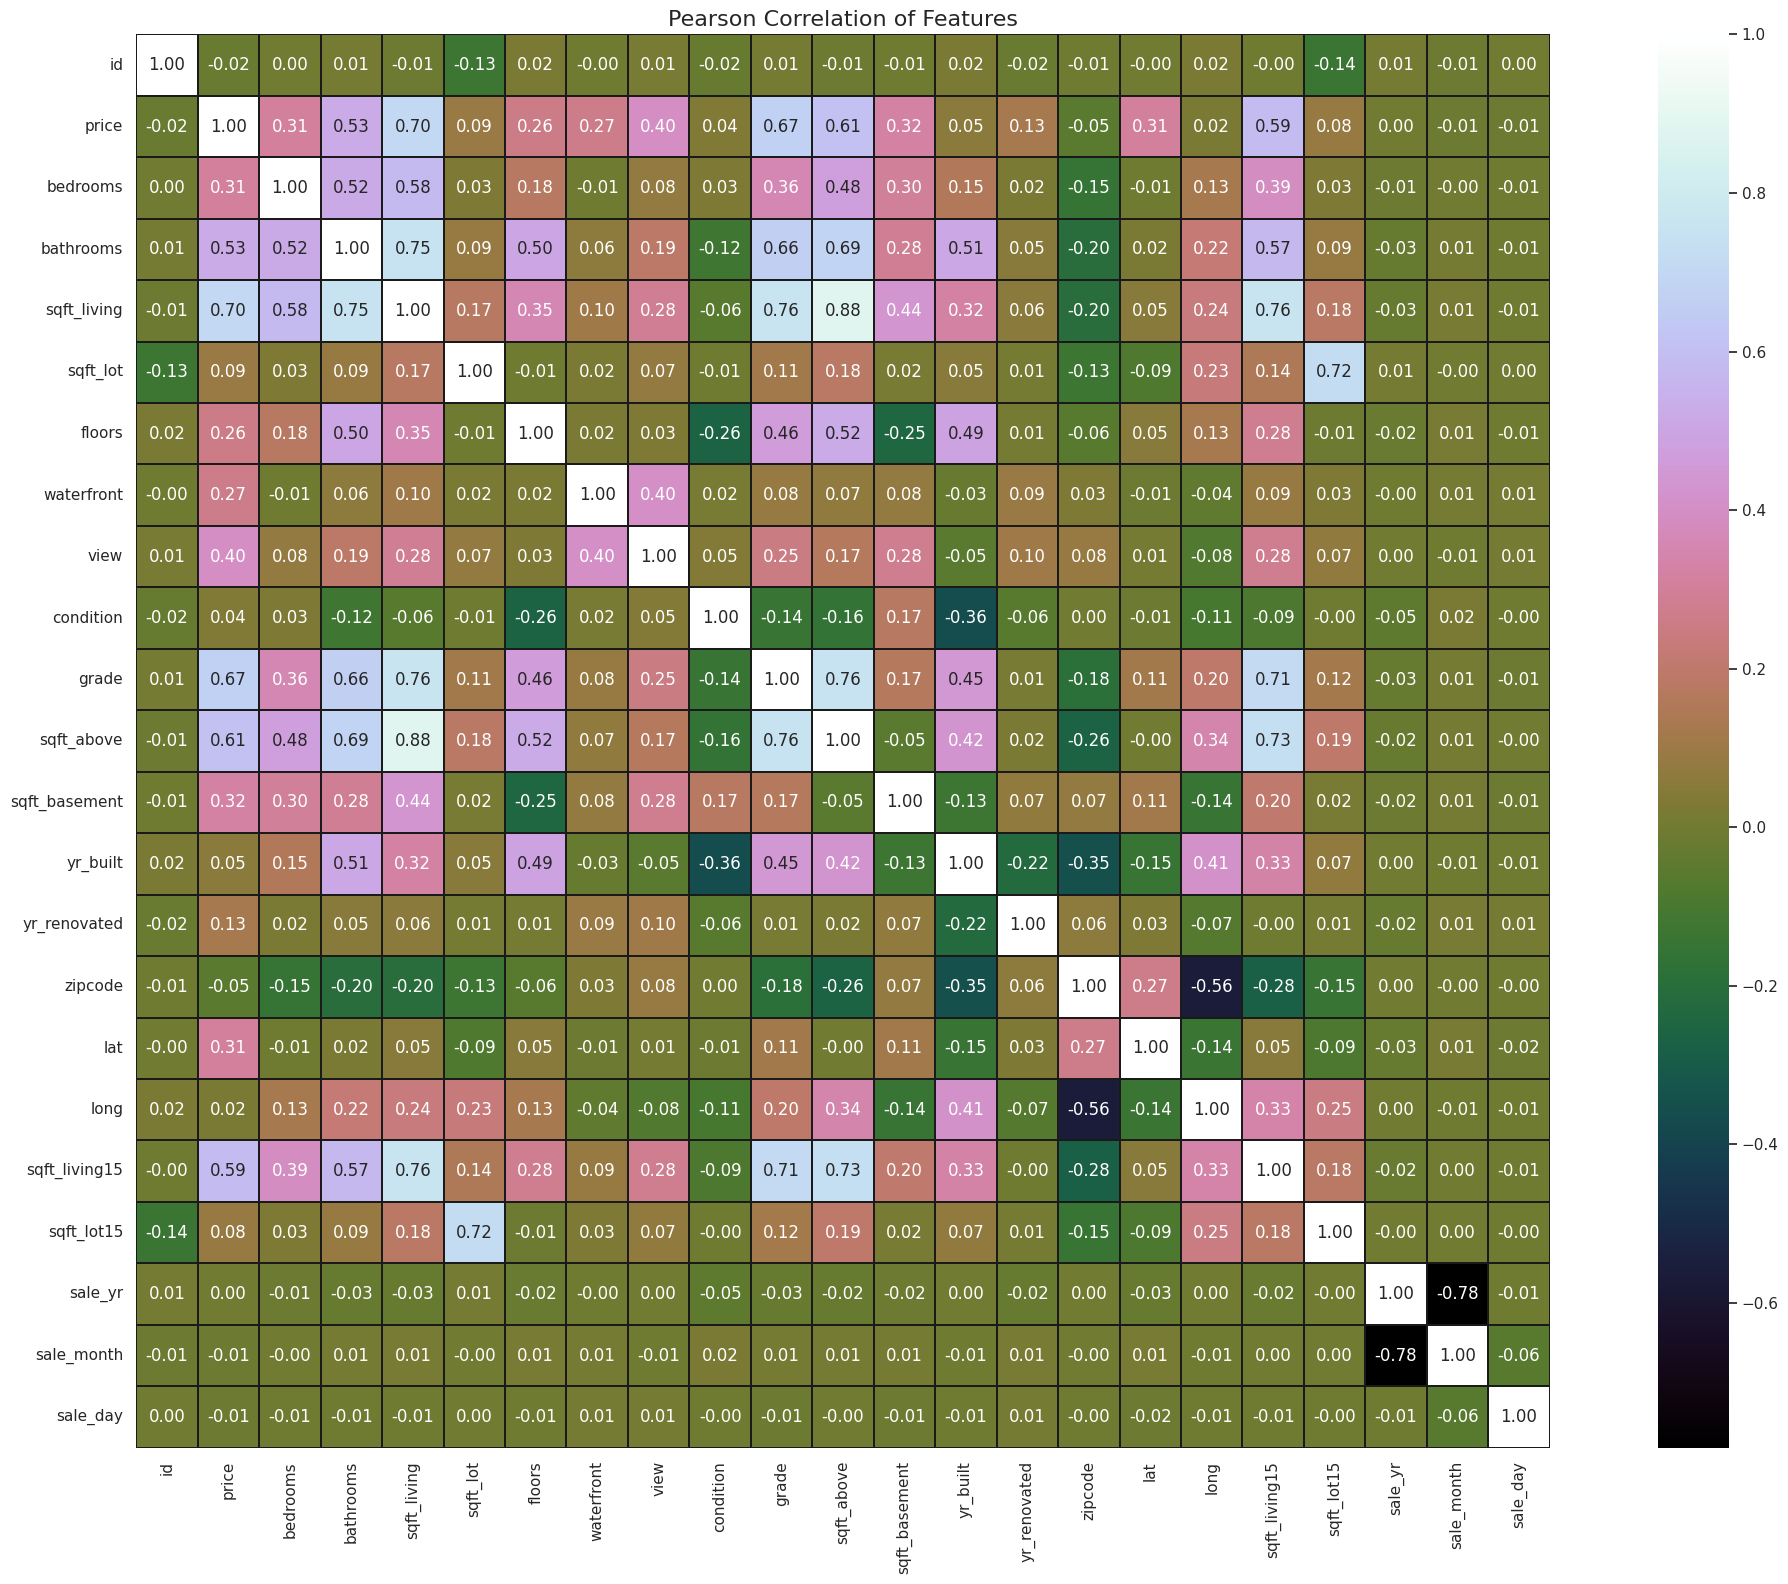

In [22]:
import os
# Pearson correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(22, 16))
sns.heatmap(
    df[num_cols].astype(float).corr(),
    linewidths=0.25, vmax=1.0, square=True,
    cmap='cubehelix', linecolor='k', annot=True, fmt='.2f', ax=ax
)
ax.set_title('Pearson Correlation of Features', fontsize=16)
plt.tight_layout()

# Create the 'results' directory if it doesn't exist
os.makedirs('results', exist_ok=True)

plt.savefig('results/correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

## 4. Train / Validation Split & Normalization

In [23]:
def train_validate_split(df, train_part=0.7, validate_part=0.3, seed=2017):
    np.random.seed(seed)
    perm = np.random.permutation(df.index)
    m = len(df)
    train_end = int(train_part * m)
    train    = perm[:train_end]
    validate = perm[train_end:]
    return train, validate

kc_train, kc_valid = train_validate_split(kc_data)

label_col = 'price'
x_train = kc_data.loc[kc_train, :].drop(label_col, axis=1)
y_train = kc_data.loc[kc_train, [label_col]]
x_valid = kc_data.loc[kc_valid, :].drop(label_col, axis=1)
y_valid = kc_data.loc[kc_valid, [label_col]]

print(f'Training samples:   {len(x_train)}')
print(f'Validation samples: {len(x_valid)}')

Training samples:   15129
Validation samples: 6484


In [10]:
# Z-score normalization using training set statistics only
train_mean = x_train.mean()
train_std  = x_train.std()

x_train_norm = (x_train - train_mean) / train_std
x_valid_norm = (x_valid - train_mean) / train_std  # same stats — no data leakage

x_train_array = np.array(x_train_norm)
y_train_array = np.array(y_train)
x_valid_array = np.array(x_valid_norm)
y_valid_array = np.array(y_valid)

print(f'Train input shape:      {x_train_array.shape}')
print(f'Validation input shape: {x_valid_array.shape}')

Train input shape:      (15129, 19)
Validation input shape: (6484, 19)


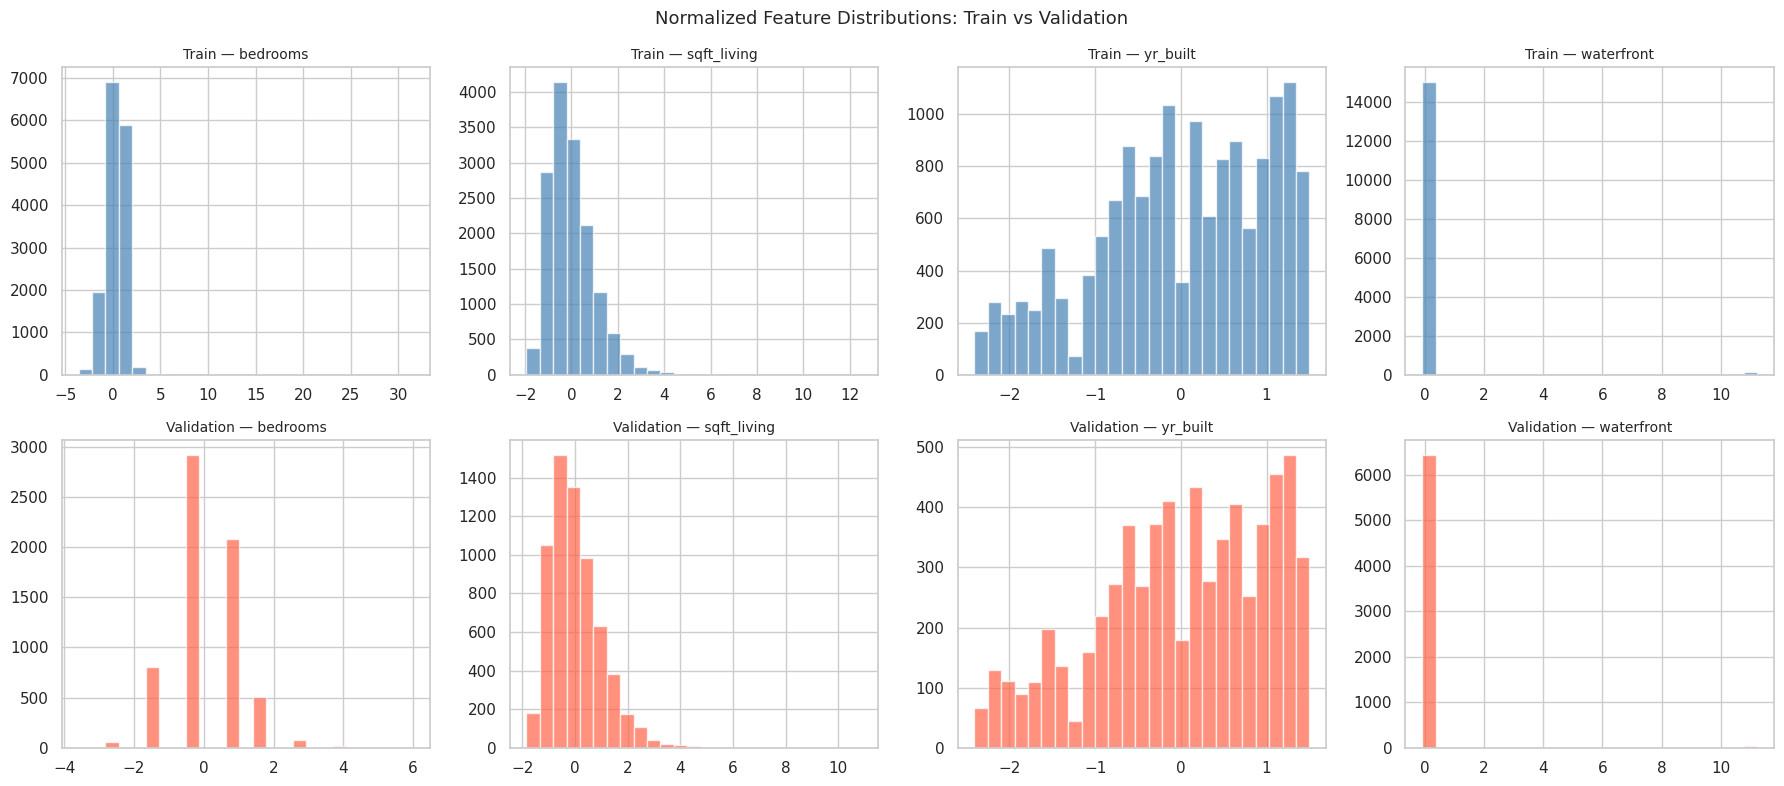

In [26]:
import os

# Create the 'results' directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Distribution of selected normalized features
features = ['bedrooms', 'sqft_living', 'yr_built', 'waterfront']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(features):
    x_train_norm[feat].hist(bins=25, ax=axes[0, i], color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'Train — {feat}', fontsize=10)
    x_valid_norm[feat].hist(bins=25, ax=axes[1, i], color='tomato', alpha=0.7)
    axes[1, i].set_title(f'Validation — {feat}', fontsize=10)

plt.suptitle('Normalized Feature Distributions: Train vs Validation', fontsize=13)
plt.tight_layout()
plt.savefig('results/normalized_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Training Utilities

In [49]:
EPOCHS     = 800
BATCH_SIZE = 128

# Removed get_lr_metric function entirely as it was causing compilation issues.

class ShowLR(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # Directly access learning_rate and convert to numpy
        lr = self.model.optimizer.learning_rate.numpy()
        if epoch % 100 == 0:
            print(f"Epoch {epoch+1:03d} — LR: {lr:.7f}")

def step_decay_schedule(initial_lr=1e-3, decay_factor=0.75, step_size=200):
    def schedule(epoch):
        return initial_lr * (decay_factor ** np.floor((epoch + 1) / step_size))
    return LearningRateScheduler(schedule)

def get_callbacks():
    return [step_decay_schedule(initial_lr=1e-3, decay_factor=0.75, step_size=200), ShowLR()]

def plot_loss_comparison(histories):
    """Plot train vs val loss for all models on the same axes."""
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = ['steelblue', 'tomato', 'seagreen']
    for (name, history), color in zip(histories, colors):
        ax.plot(history.history['loss'],     color=color, linestyle='-',  linewidth=1, label=f'{name} Train')
        ax.plot(history.history['val_loss'], color=color, linestyle='--', linewidth=1, label=f'{name} Val')
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, log scale)')
    ax.set_title('Train vs Validation Loss — Model Comparison')
    ax.legend()
    ax.grid(True, which='both', linestyle='--')
    plt.tight_layout()
    plt.savefig('results/loss_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

def plot_single_loss(history, title, filename):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(history.history['loss'],     linewidth=1, label='Train')
    ax.plot(history.history['val_loss'], linewidth=1, label='Validation')
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', linestyle='--')
    plt.tight_layout()
    plt.savefig(f'results/{filename}', bbox_inches='tight', dpi=150)
    plt.show()

## 6. Model 1 — Basic MLP (Baseline)

In [43]:
def build_basic_model(x_size, y_size):
    adam = Adam()
    model = Sequential([
        Dense(80,  activation='tanh', kernel_initializer='normal', input_shape=(x_size,)),
        Dense(160, activation='relu', kernel_initializer='normal'),
        Dense(160, activation='relu', kernel_initializer='normal'),
        Dense(80,  activation='relu', kernel_initializer='normal'),
        Dense(40,  activation='relu', kernel_initializer='normal'),
        Dense(y_size)
    ])
    # Removed get_lr_metric(adam) from metrics as it causes Toutput_types error
    model.compile(loss='mean_squared_error', optimizer=adam,
                  metrics=[metrics.mae])
    return model

model_basic = build_basic_model(x_train_array.shape[1], y_train_array.shape[1])
model_basic.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 80)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 160)            │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 80)             │        12,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,481 (220.63 KB)

 Trainable params: 56,481 (220.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 001 — LR: 0.0010000
Epoch 101 — LR: 0.0010000
Epoch 201 — LR: 0.0007500
Epoch 301 — LR: 0.0007500
Epoch 401 — LR: 0.0005625
Epoch 501 — LR: 0.0005625
Epoch 601 — LR: 0.0004219
Epoch 701 — LR: 0.0004219
Training time: 0:07:04.045940
Basic — Train MAE: 39120.6914, Val MAE: 85617.7656


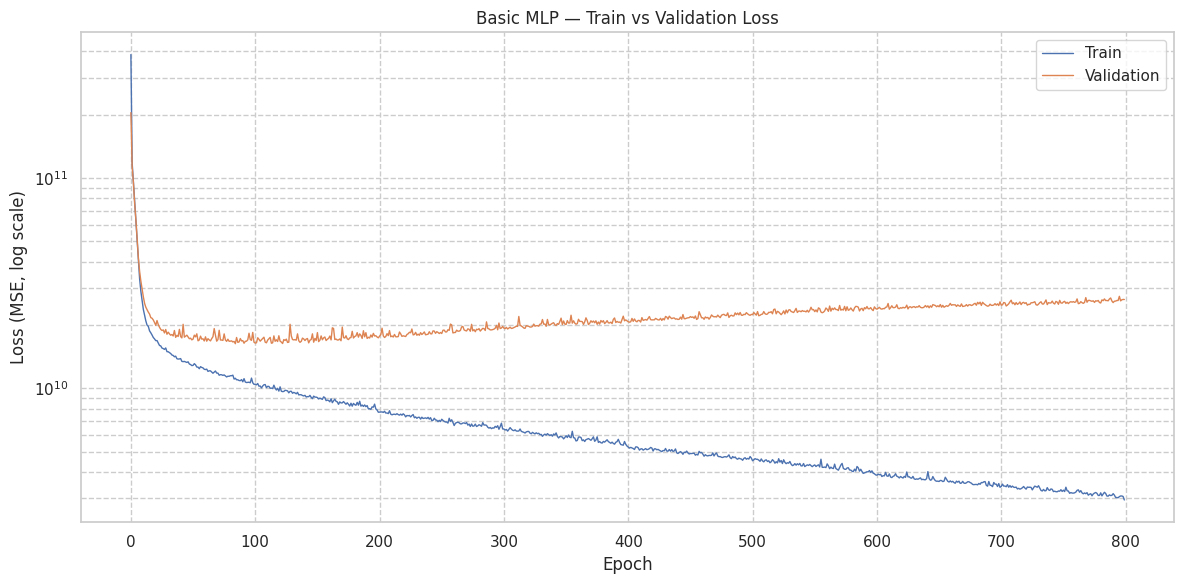

In [46]:
start = datetime.now()
history_basic = model_basic.fit(
    x_train_array, y_train_array,
    batch_size=BATCH_SIZE, epochs=EPOCHS, shuffle=True,
    validation_data=(x_valid_array, y_valid_array),
    callbacks=get_callbacks(), verbose=0
)
print(f'Training time: {datetime.now() - start}')

score_train_basic = model_basic.evaluate(x_train_array, y_train_array, verbose=0)
score_valid_basic = model_basic.evaluate(x_valid_array, y_valid_array, verbose=0)
print(f'Basic — Train MAE: {score_train_basic[1]:.4f}, Val MAE: {score_valid_basic[1]:.4f}')

plot_single_loss(history_basic, 'Basic MLP — Train vs Validation Loss', 'loss_basic.png')

## 7. Model 2 — MLP with Dropout

In [44]:
def build_dropout_model(x_size, y_size):
    adam = Adam()
    model = Sequential([
        Dense(80,  activation='tanh', kernel_initializer='normal', input_shape=(x_size,)),
        Dropout(0.2),
        Dense(160, activation='relu', kernel_initializer='normal'),
        Dropout(0.5),
        Dense(160, activation='relu', kernel_initializer='normal'),
        Dropout(0.5),
        Dense(80,  activation='relu', kernel_initializer='normal'),
        Dropout(0.5),
        Dense(40,  activation='relu', kernel_initializer='normal'),
        Dropout(0.5),
        Dense(y_size)
    ])
    # Removed get_lr_metric(adam) from metrics as it causes Toutput_types error
    model.compile(loss='mean_squared_error', optimizer=adam,
                  metrics=[metrics.mae])
    return model

model_dropout = build_dropout_model(x_train_array.shape[1], y_train_array.shape[1])
model_dropout.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 80)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 160)            │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 80)             │        12,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,481 (220.63 KB)

 Trainable params: 56,481 (220.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 001 — LR: 0.0010000
Epoch 101 — LR: 0.0010000
Epoch 201 — LR: 0.0007500
Epoch 301 — LR: 0.0007500
Epoch 401 — LR: 0.0005625
Epoch 501 — LR: 0.0005625
Epoch 601 — LR: 0.0004219
Epoch 701 — LR: 0.0004219
Training time: 0:07:15.762709
Dropout — Train MAE: 72423.6406, Val MAE: 78537.3516


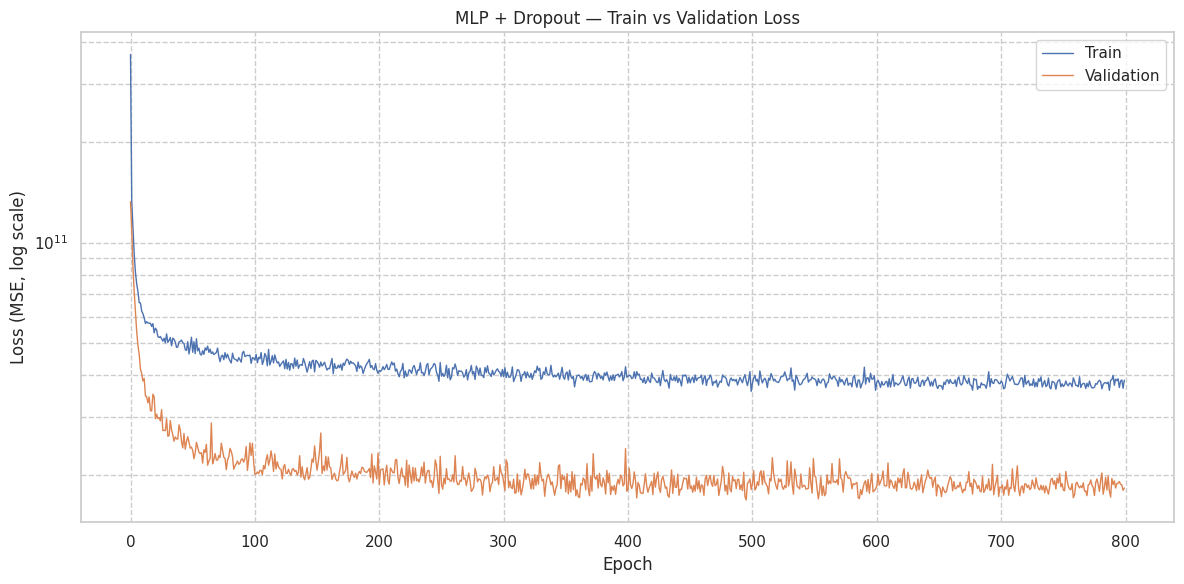

In [47]:
start = datetime.now()
history_dropout = model_dropout.fit(
    x_train_array, y_train_array,
    batch_size=BATCH_SIZE, epochs=EPOCHS, shuffle=True,
    validation_data=(x_valid_array, y_valid_array),
    callbacks=get_callbacks(), verbose=0
)
print(f'Training time: {datetime.now() - start}')

score_train_dropout = model_dropout.evaluate(x_train_array, y_train_array, verbose=0)
score_valid_dropout = model_dropout.evaluate(x_valid_array, y_valid_array, verbose=0)
print(f'Dropout — Train MAE: {score_train_dropout[1]:.4f}, Val MAE: {score_valid_dropout[1]:.4f}')

plot_single_loss(history_dropout, 'MLP + Dropout — Train vs Validation Loss', 'loss_dropout.png')

## 8. Model 3 — MLP with L2 Regularization

In [45]:
def build_l2_model(x_size, y_size, l2_lambda=0.01):
    adam = Adam()
    reg = l2(l2_lambda)
    model = Sequential([
        Dense(6,  activation='tanh', kernel_initializer='normal', kernel_regularizer=reg, input_shape=(x_size,)),
        Dense(4,  activation='relu', kernel_initializer='normal', kernel_regularizer=reg),
        Dense(11, activation='relu', kernel_initializer='normal', kernel_regularizer=reg),
        Dense(6,  activation='relu', kernel_initializer='normal', kernel_regularizer=reg),
        Dense(8,  activation='relu', kernel_initializer='normal', kernel_regularizer=reg),
        Dense(y_size)
    ])
    # Removed get_lr_metric(adam) from metrics as it causes Toutput_types error
    model.compile(loss='mean_squared_error', optimizer=adam,
                  metrics=[metrics.mae])
    return model

model_l2 = build_l2_model(x_train_array.shape[1], y_train_array.shape[1])
model_l2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 6)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 11)             │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340 (1.33 KB)

 Trainable params: 340 (1.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 001 — LR: 0.0010000
Epoch 101 — LR: 0.0010000
Epoch 201 — LR: 0.0007500
Epoch 301 — LR: 0.0007500
Epoch 401 — LR: 0.0005625
Epoch 501 — LR: 0.0005625
Epoch 601 — LR: 0.0004219
Epoch 701 — LR: 0.0004219
Training time: 0:07:05.564005
L2 — Train MAE: 87612.8281, Val MAE: 88732.1484


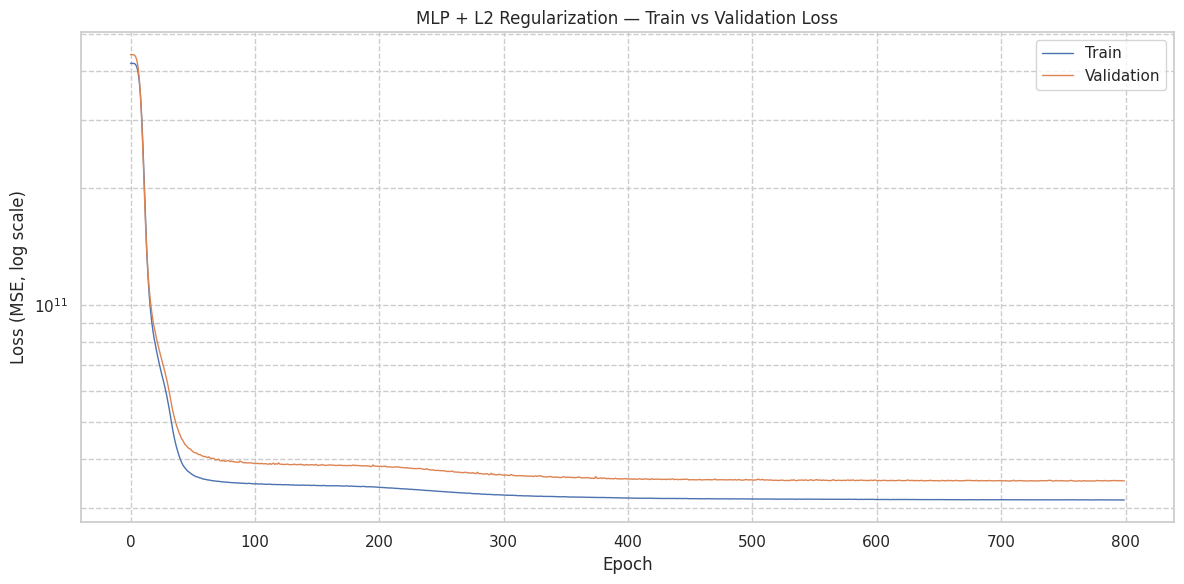

In [48]:
start = datetime.now()
history_l2 = model_l2.fit(
    x_train_array, y_train_array,
    batch_size=BATCH_SIZE, epochs=EPOCHS, shuffle=True,
    validation_data=(x_valid_array, y_valid_array),
    callbacks=get_callbacks(), verbose=0
)
print(f'Training time: {datetime.now() - start}')

score_train_l2 = model_l2.evaluate(x_train_array, y_train_array, verbose=0)
score_valid_l2 = model_l2.evaluate(x_valid_array, y_valid_array, verbose=0)
print(f'L2 — Train MAE: {score_train_l2[1]:.4f}, Val MAE: {score_valid_l2[1]:.4f}')

plot_single_loss(history_l2, 'MLP + L2 Regularization — Train vs Validation Loss', 'loss_l2.png')

## 9. Model Comparison

In [51]:
# Summary table
results = pd.DataFrame({
    'Model':      ['Basic MLP', 'MLP + Dropout', 'MLP + L2'],
    'Train MAE':  [score_train_basic[1], score_train_dropout[1], score_train_l2[1]],
    'Val MAE':    [score_valid_basic[1], score_valid_dropout[1], score_valid_l2[1]],
    'Train Loss': [score_train_basic[0], score_train_dropout[0], score_train_l2[0]],
    'Val Loss':   [score_valid_basic[0], score_valid_dropout[0], score_valid_l2[0]],
})
results = results.round(4)
print(results.to_string(index=False))

        Model  Train MAE    Val MAE   Train Loss     Val Loss
    Basic MLP 39120.6914 85617.7656 2.862233e+09 2.645177e+10
MLP + Dropout 72423.6406 78537.3516 1.275146e+10 1.834605e+10
     MLP + L2 87612.8281 88732.1484 3.134625e+10 3.516663e+10


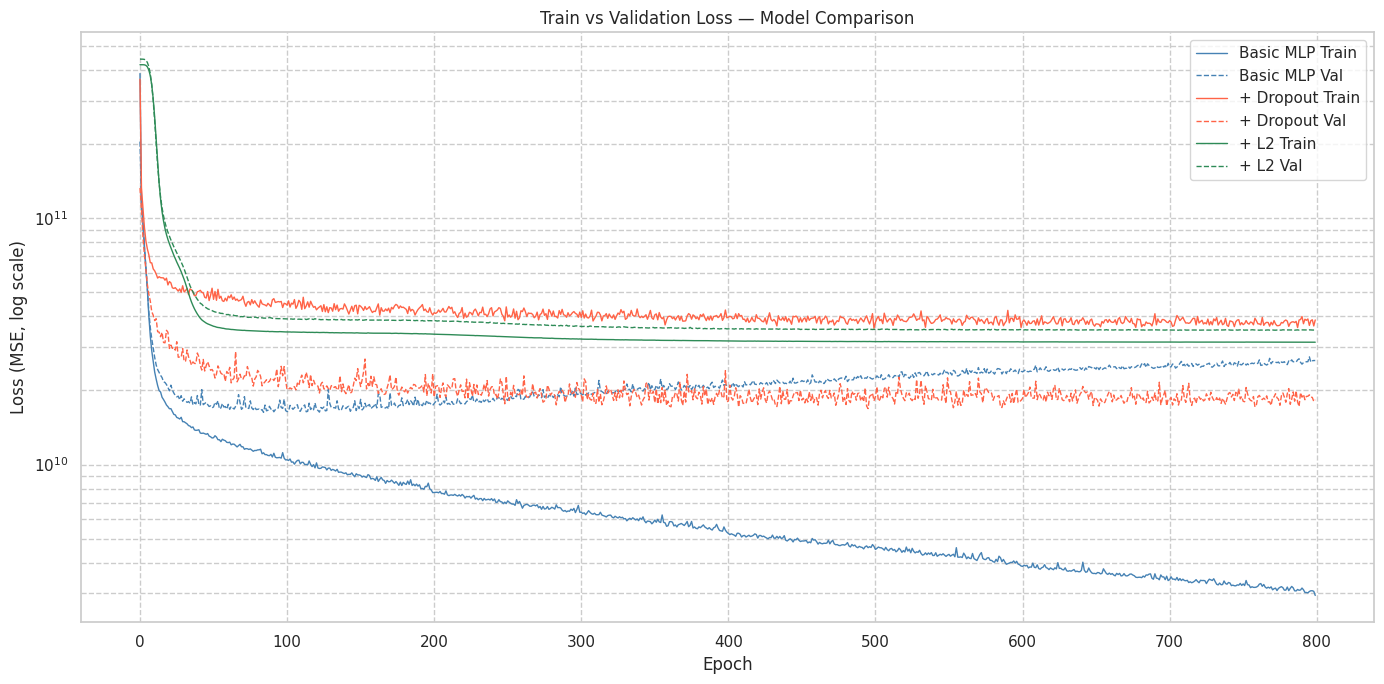

In [52]:
# Side-by-side loss curves for all 3 models
plot_loss_comparison([
    ('Basic MLP',     history_basic),
    ('+ Dropout',     history_dropout),
    ('+ L2',          history_l2)
])